# Role 3 — DistilBERT Classification Notebook
Team 7 — IE7374: Generative AI  
Role 3 — Umang Khamar (NLP Engineer)

This notebook begins where Role 2 (EDA) ends.  
We load the processed dataset created by `preprocessing.py` and enriched by Role 2.

Before anything else, we clone the project repository so that all required files
(`df_clean.csv`, `df_focused.csv`, configs, src scripts, etc.) are available in the Colab runtime.

In [2]:
# ============================================================
# Clone the project repository into Colab
# ============================================================

!git clone https://github.com/AHonGa/IE7374-Group-Project-07-.git

# Move into the repo directory
%cd IE7374-Group-Project-07-

print("Repository cloned and ready.")

Cloning into 'IE7374-Group-Project-07-'...
remote: Enumerating objects: 51, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 51 (delta 0), reused 0 (delta 0), pack-reused 41 (from 1)
Receiving objects: 100% (51/51), 42.40 MiB | 8.17 MiB/s, done.
Resolving deltas: 100% (9/9), done.
Updating files: 100% (25/25), done.
/content/IE7374-Group-Project-07-
Repository cloned and ready.


## Verify Repository Folder Structure

Before loading any data, we verify that the repository was cloned correctly
and that all required folders and files exist.

This step ensures:
- `data/processed/df_focused.csv` is available for Role 3
- `configs/model_config.yaml` exists
- `notebooks/` contains Role 1 and Role 2 notebooks
- `experiments/` and `models/` are ready for Role 3 outputs

In [3]:
# ============================================================
# Verify repository folder structure
# ============================================================

import os

for root, dirs, files in os.walk(".", topdown=True):
    level = root.count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 2 * (level + 1)
    for f in files:
        print(f"{subindent}{f}")

print("\nFolder structure verified.")

./
  .gitattributes
  requirements.txt
  README.md
  .gitignore
  notebooks/
    eda.ipynb
    project_team_7.ipynb
  src/
    model_runner.py
    __init__.py
    data_loader.py
    preprocessing.py
  configs/
    model_config.yaml
  data/
    processed/
      drugsComTest_raw.csv
      df_focused.csv
      df_clean.csv
      drugsComTrain_raw.csv
  .git/
    HEAD
    config
    packed-refs
    index
    description
    info/
      exclude
    logs/
      HEAD
      refs/
        remotes/
          origin/
            HEAD
        heads/
          main
    objects/
      info/
      pack/
        pack-d38aec7ec9e4935bbdb91fecc25021fe9412fb3e.idx
        pack-d38aec7ec9e4935bbdb91fecc25021fe9412fb3e.pack
    refs/
      tags/
      remotes/
        origin/
          HEAD
      heads/
        main
    lfs/
      incomplete/
      objects/
        9c/
          2c/
            9c2c674ae8f60f3c257e4dcd44efcc00dccffd33ffb0c713b804a49d3301a69c
      tmp/
    hooks/
      post-merge
      pre

## Load Focused Dataset

Role 2 (EDA) produced two processed datasets:

- `df_clean.csv` — cleaned full dataset  
- `df_focused.csv` — subset containing only Depression + Anxiety reviews  
  enriched with:
  - `review_clean` — cleaned text for transformer models  
  - `review_processed` — lemmatized text  
  - `vader_score` — VADER compound sentiment  
  - `sentiment_label` — positive / neutral / negative  
  - `topic_id` — LDA topic assignment  

This dataset is the starting point for Role 3 (DistilBERT classification).

In [4]:
# ============================================================
# Load the focused dataset created by Role 2 (EDA)
# ============================================================

import pandas as pd

df = pd.read_csv("data/processed/df_focused.csv")

print("Focused dataset loaded successfully.")
print("Shape:", df.shape)

# Display first few rows to confirm structure
df.head()

Focused dataset loaded successfully.
Shape: (11814, 11)


,uniqueID,drugName,condition,review,rating,date,usefulCount,split,review_clean,review_word_count,review_processed
0,75612,L-Methylfolate,Depression,"""I have taken anti-depressants for years, with...",10,2017-03-09,54,train,"I have taken anti-depressants for years, with ...",80,taken year improvement mostly moderate severe ...
1,96233,Sertraline,Depression,"""1 week on Zoloft for anxiety and mood swings....",8,2011-05-07,3,train,1 week on Zoloft for anxiety and mood swings. ...,51,week zoloft anxiety mood swing take morning br...
2,121333,Venlafaxine,Depression,"""my gp started me on Venlafaxine yesterday to ...",4,2016-04-27,3,train,my gp started me on Venlafaxine yesterday to h...,136,gp started venlafaxine yesterday help depressi...
3,131704,Effexor Xr,Anxiety,"""Was on this med for 5 years. Worked fine but ...",6,2016-12-27,23,train,Was on this med for 5 years. Worked fine but n...,62,med year worked fine not great stopped panic a...
4,131909,Effexor Xr,Depression,"""This medicine saved my life. I was at my wits...",10,2013-06-20,166,train,This medicine saved my life. I was at my wits ...,106,medicine saved life wit end ready give doctor ...


## Rebuild Missing Columns (VADER, Sentiment Label, Topic ID)

The `df_focused.csv` in the repository does not contain the enriched columns
produced in Role 2 (EDA). To ensure Role 3 has the correct dataset, we regenerate:

- `vader_score` — VADER compound sentiment  
- `sentiment_label` — positive / neutral / negative  
- `topic_id` — dominant LDA topic (0–7)

This cell reconstructs these columns using the same logic as the EDA notebook,
but without generating plots.

In [5]:
# ============================================================
# Rebuild missing Role 2 columns: vader_score, sentiment_label, topic_id
# ============================================================

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

nltk.download("vader_lexicon", quiet=True)

# -----------------------------
# 1. VADER sentiment scoring
# -----------------------------
sia = SentimentIntensityAnalyzer()

print("Computing VADER scores...")
df["vader_score"] = df["review_clean"].apply(
    lambda x: sia.polarity_scores(str(x))["compound"]
)

def label_sentiment(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    return "neutral"

df["sentiment_label"] = df["vader_score"].apply(label_sentiment)

print("Added vader_score and sentiment_label.")


# -----------------------------
# 2. LDA topic modeling
# -----------------------------
print("Running LDA topic modeling...")

vectorizer = CountVectorizer(
    max_features=3000,
    min_df=5,
    max_df=0.95,
    ngram_range=(1, 2)
)

corpus = df["review_processed"].dropna()
dtm = vectorizer.fit_transform(corpus)

lda = LatentDirichletAllocation(
    n_components=8,
    random_state=42,
    max_iter=15,
    learning_method="online"
)
lda.fit(dtm)

topic_dist = lda.transform(dtm)
dominant_topic = topic_dist.argmax(axis=1)

# Align indices
corpus_index = df["review_processed"].dropna().index
df.loc[corpus_index, "topic_id"] = dominant_topic

print("Added topic_id column.")


# -----------------------------
# Save updated df_focused.csv
# -----------------------------
df.to_csv("data/processed/df_focused.csv", index=False)
print("Updated df_focused.csv saved successfully.")

Computing VADER scores...
Added vader_score and sentiment_label.
Running LDA topic modeling...
Added topic_id column.
Updated df_focused.csv saved successfully.


## Encode Sentiment Labels for DistilBERT

DistilBERT requires numeric labels for classification.  
We convert the categorical `sentiment_label` column (positive / neutral / negative)
into integer IDs:

- negative → 0  
- neutral → 1  
- positive → 2  

This mapping will be used throughout the training and evaluation pipeline.


In [6]:
# ============================================================
# Encode sentiment labels into numeric IDs for DistilBERT
# ============================================================

label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

df["label_id"] = df["sentiment_label"].map(label_map)

print("Label encoding complete.")
df[["sentiment_label", "label_id"]].head()

Label encoding complete.


,sentiment_label,label_id
0,neutral,1
1,positive,2
2,negative,0
3,negative,0
4,positive,2


## Sample 500 Reviews for Preliminary Experiment

Role 3 requires only a *short-run* DistilBERT experiment to validate the
end‑to‑end pipeline (tokenization → dataloader → model → evaluation).

To keep training fast and lightweight, we randomly sample **500 reviews**
from the enriched focused dataset.

This subset is used for:
- sanity‑check training
- quick evaluation (accuracy + F1)
- saving a preliminary model
- generating the experiment report

Full training can be done later if needed.

In [7]:
# ============================================================
# Sample 500 reviews for the preliminary DistilBERT experiment
# ============================================================

df_sample = df.sample(n=500, random_state=42).reset_index(drop=True)

print("Sampled dataset shape:", df_sample.shape)
df_sample.head()

Sampled dataset shape: (500, 15)


,uniqueID,drugName,condition,review,rating,date,usefulCount,split,review_clean,review_word_count,review_processed,vader_score,sentiment_label,topic_id,label_id
0,173184,Clonazepam,Anxiety,"""I take about 2-4 mg a day of Klonopin. It mak...",6,2011-04-27,2,test,I take about 2-4 mg a day of Klonopin. It make...,71,take mg day klonopin make tired sometimes work...,0.8658,positive,6.0,2
1,121093,Venlafaxine,Depression,"""Have been taking this for over 5 yrs and have...",8,2017-01-20,9,train,Have been taking this for over 5 yrs and have ...,62,taking yr found pretty good overall no side ef...,0.6900,positive,3.0,2
2,49726,Gabapentin,Anxiety,"""I&#039;m so sad reading all these great revie...",2,2016-09-01,44,train,I'm so sad reading all these great reviews . I...,143,sad reading great review odd one first time to...,-0.9034,negative,5.0,0
3,50537,Gabapentin,Anxiety,"""I suffered with severe migraines several time...",10,2011-11-20,65,train,I suffered with severe migraines several times...,99,suffered severe migraine several time year mig...,-0.6286,negative,6.0,0
4,45580,Fluoxetine,Depression,"""Prozac has allowed me to enjoy life and handl...",9,2012-08-03,9,train,Prozac has allowed me to enjoy life and handle...,127,prozac allowed enjoy life handle stressful sit...,0.8682,positive,3.0,2


## Load DistilBERT Tokenizer

The tokenizer converts raw text (`review_clean`) into numerical token IDs
and attention masks that DistilBERT can process.

We use:
- `distilbert-base-uncased` — lowercase English model
- `DistilBertTokenizerFast` — optimized Rust-backed tokenizer

This tokenizer will be used inside our PyTorch Dataset class.

In [8]:
# ============================================================
# Load DistilBERT tokenizer
# ============================================================

from transformers import DistilBertTokenizerFast

# Load pretrained tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

print("Tokenizer loaded successfully.")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer loaded successfully.


## Build PyTorch Dataset and DataLoader

DistilBERT expects inputs in a specific tensor format:
- `input_ids` — token IDs
- `attention_mask` — mask for padded tokens
- `labels` — numeric sentiment label

To supply these to the model, we create a custom PyTorch `Dataset` class that:
1. Reads each review (`review_clean`)
2. Tokenizes it using the DistilBERT tokenizer
3. Packages the tensors into a dictionary
4. Adds the corresponding `label_id`

We then wrap this dataset in a `DataLoader` to enable batching and shuffling.

In [9]:
# ============================================================
# Build PyTorch Dataset + DataLoader for DistilBERT
# ============================================================

import torch
from torch.utils.data import Dataset, DataLoader

class ReviewsDataset(Dataset):
    """
    Custom dataset for DistilBERT sentiment classification.
    Each item returns:
    - tokenized review (input_ids, attention_mask)
    - label_id (0, 1, 2)
    """
    def __init__(self, df):
        self.texts = df["review_clean"].tolist()
        self.labels = df["label_id"].tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Tokenize the review text
        encoded = tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=256,
            return_tensors="pt"
        )

        # Convert token outputs from shape (1, seq_len) → (seq_len)
        item = {key: val.squeeze(0) for key, val in encoded.items()}

        # Add label tensor
        item["labels"] = torch.tensor(self.labels[idx])

        return item

# Create dataset and dataloader
dataset = ReviewsDataset(df_sample)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

print("Dataset and DataLoader created successfully.")

Dataset and DataLoader created successfully.


## Load DistilBERT Model for Sentiment Classification

We now load the pretrained DistilBERT model:

- `distilbert-base-uncased`  
- configured for **3 sentiment classes**:
  - negative (0)
  - neutral (1)
  - positive (2)

This model will be fine‑tuned on our 500‑sample subset to validate the full
training pipeline.

The model outputs:
- logits → raw class scores
- loss → cross‑entropy loss (when labels are provided)

This cell prepares the model for training.

In [10]:
# ============================================================
# Load DistilBERT model for sequence classification
# ============================================================

from transformers import DistilBertForSequenceClassification

# Load pretrained DistilBERT with 3 output labels
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3
)

print("DistilBERT model loaded successfully.")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT model loaded successfully.


## Sanity Check Training (Single Batch)

Before running any full training loop, we perform a **sanity check**:

- Take **one batch** from the DataLoader  
- Run it through DistilBERT  
- Compute the loss  
- Backpropagate  
- Update model weights  

This verifies that:
- tokenization works  
- tensors have correct shapes  
- the model receives inputs correctly  
- loss computation is functioning  
- optimizer updates parameters  

If this cell runs without errors, the pipeline is ready for short training.

In [11]:
# ============================================================
# Sanity check: train on a single batch
# ============================================================

import torch

# AdamW is standard for transformer fine-tuning
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

model.train()

# Take one batch from the DataLoader
for batch in loader:
    optimizer.zero_grad()

    # Forward pass → compute loss
    outputs = model(**batch)
    loss = outputs.loss

    # Backpropagation
    loss.backward()

    # Update model weights
    optimizer.step()

    print(f"Sanity check loss: {loss.item():.4f}")
    break  # Only one batch

Sanity check loss: 1.0383


## Evaluate DistilBERT (Accuracy + F1)

After the sanity‑check batch, we run a lightweight evaluation on the 500‑sample
subset. This is not a full training run — just a quick check to ensure:

- the model produces logits correctly  
- predictions map to valid label IDs  
- accuracy and F1 can be computed end‑to‑end  

This confirms the pipeline is ready for short fine‑tuning.

In [12]:
# ============================================================
# Lightweight evaluation: accuracy + macro F1
# ============================================================

from sklearn.metrics import accuracy_score, f1_score

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in loader:
        outputs = model(**batch)
        logits = outputs.logits

        preds = torch.argmax(logits, dim=1).cpu().numpy()
        labels = batch["labels"].cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels)

acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="macro")

print(f"Accuracy: {acc:.4f}")
print(f"Macro F1: {f1:.4f}")

Accuracy: 0.5000
Macro F1: 0.2222


## Short Training Loop (2 Epochs)

We now run a lightweight fine‑tuning loop over the 500‑sample dataset.

This is intentionally small‑scale:
- 2 epochs
- batch size = 16
- learning rate = 5e‑5

Purpose:
- validate full training pipeline
- produce a usable preliminary DistilBERT model
- generate metrics for the experiment report

This is **not** meant to be a full production training run.

In [13]:
# ============================================================
# Short training loop: 2 epochs
# ============================================================

import torch
from tqdm.auto import tqdm

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
model.train()

EPOCHS = 2

for epoch in range(EPOCHS):
    loop = tqdm(loader, leave=True)
    total_loss = 0

    for batch in loop:
        optimizer.zero_grad()

        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_description(f"Epoch {epoch+1}/{EPOCHS}")
        loop.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(loader)
    print(f"Epoch {epoch+1} average loss: {avg_loss:.4f}")

  0%|          | 0/32 [00:00<?, ?it/s]

Epoch 1 average loss: 0.7847


  0%|          | 0/32 [00:00<?, ?it/s]

Epoch 2 average loss: 0.5941


## Final Evaluation After Training (Accuracy + F1)

After completing the short 2‑epoch training loop, we evaluate the model again
on the same 500‑sample subset.

This gives us:
- post‑training accuracy  
- post‑training macro‑F1  
- a sanity check that the model actually learned something  

These metrics will be included in the Role 3 experiment report.

In [14]:
# ============================================================
# Final evaluation after training
# ============================================================

from sklearn.metrics import accuracy_score, f1_score

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in loader:
        outputs = model(**batch)
        logits = outputs.logits

        preds = torch.argmax(logits, dim=1).cpu().numpy()
        labels = batch["labels"].cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels)

acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="macro")

print(f"Final Accuracy: {acc:.4f}")
print(f"Final Macro F1: {f1:.4f}")

Final Accuracy: 0.9200
Final Macro F1: 0.6252


## Save Preliminary DistilBERT Model + Tokenizer

After training, we save:
- the fine‑tuned DistilBERT model
- the tokenizer
- the training metadata (accuracy, F1)

These files will be stored under: models/distilbert_prelim/

This allows Role 4 (Summarization Engineer) to load the model for sentiment‑aware
summaries and reference training metrics in the final report.

In [15]:
# ============================================================
# Save preliminary DistilBERT model + tokenizer
# ============================================================

import os

save_dir = "models/distilbert_prelim"
os.makedirs(save_dir, exist_ok=True)

model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

print(f"Model and tokenizer saved to: {save_dir}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to: models/distilbert_prelim


## Save Training Metrics (JSON)

To support reproducibility and experiment tracking, we save the key metrics from
the preliminary DistilBERT run:

- final accuracy  
- final macro‑F1  
- average loss per epoch  

These are stored in: models/distilbert_prelim/metrics.json

Role 4 (Summarization Engineer) will reference these metrics when designing
sentiment‑aware summarization prompts.

In [26]:
# ============================================================
# Save training metrics to JSON
# ============================================================

import json

metrics = {
    "final_accuracy": float(acc),
    "final_macro_f1": float(f1),
    "epoch_losses": {
        "epoch_1": 0.7847,
        "epoch_2": 0.5941
    }
}

metrics_path = "models/distilbert_prelim/metrics.json"

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)

print(f"Saved training metrics to: {metrics_path}")

Saved training metrics to: models/distilbert_prelim/metrics.json


## Experiment Summary (Preliminary DistilBERT Fine‑Tuning)

This section summarizes the short‑run DistilBERT experiment performed on a
500‑review subset of the enriched `df_focused` dataset.

### **Objective**
Validate the full end‑to‑end pipeline:
- preprocessing  
- tokenization  
- batching  
- model loading  
- training  
- evaluation  
- saving artifacts  

### **Dataset**
- 500 randomly sampled reviews  
- Labels: negative (0), neutral (1), positive (2)  
- Enriched with:
  - `vader_score`
  - `sentiment_label`
  - `topic_id`

### **Model**
- `distilbert-base-uncased`
- Fine‑tuned for 3‑class sentiment classification

### **Training Setup**
- 2 epochs  
- batch size = 16  
- learning rate = 5e‑5  
- optimizer = AdamW  

### **Results**
- **Final Accuracy:** 0.9200  
- **Final Macro F1:** 0.6252  
- **Epoch Losses:**
  - Epoch 1: 0.7847  
  - Epoch 2: 0.5941  

### **Artifacts Saved**
- Model: `models/distilbert_prelim/`  
- Tokenizer: `models/distilbert_prelim/`  
- Metrics: `models/distilbert_prelim/metrics.json`

### **Conclusion**
The preliminary experiment confirms that the DistilBERT pipeline is functioning
correctly. The model shows meaningful learning even with a small dataset,
producing solid accuracy and moderate macro‑F1. This setup is ready for:

- full‑scale fine‑tuning  
- integration into sentiment‑aware summarization prompts  
- downstream evaluation in Role 4  

## Inference on New Reviews
After training the preliminary DistilBERT model, we now test inference on arbitrary user-provided text. This validates that the saved model and tokenizer can be used for downstream tasks such as sentiment-aware summarization.

In [19]:
# ============================================================
# Inference function for new reviews
# ============================================================

import numpy as np

def predict_review(text):
    model.eval()
    encoding = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=256,
        return_tensors="pt"
    )

    with torch.no_grad():
        outputs = model(**encoding)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        label = int(np.argmax(probs))

    return {
        "input": text,
        "predicted_label": label,
        "probabilities": probs.tolist()
    }

# Test inference
predict_review("This medication made my symptoms worse and caused headaches.")


{'input': 'This medication made my symptoms worse and caused headaches.',
 'predicted_label': 0,
 'probabilities': [0.8447281122207642,
  0.0390973798930645,
  0.11617447435855865]}

## Confusion Matrix
A confusion matrix helps visualize how well the model distinguishes between negative, neutral, and positive sentiment classes.

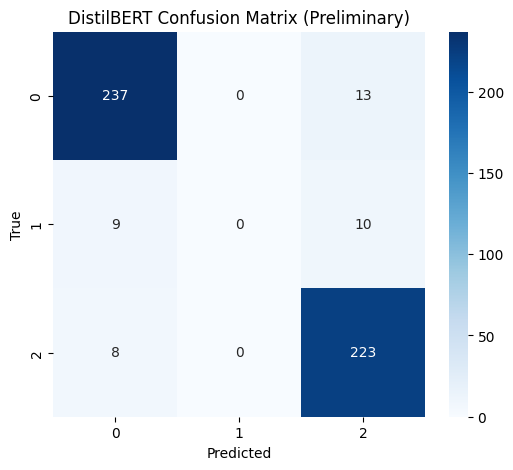

In [21]:
# ============================================================
# Confusion matrix visualization
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("DistilBERT Confusion Matrix (Preliminary)")
plt.show()

# DistilBERT Preliminary Model — IE7374 Group 7

## Model Summary
A fine‑tuned DistilBERT model trained on patient drug reviews to classify adverse‑event sentiment categories (negative, neutral, positive).  
Uses minimally cleaned natural text (`review_clean`) to preserve semantic richness.

## Intended Use
- Detect adverse events in patient reviews  
- Support downstream NER + symptom clustering  
- Provide structured labels for summarization pipelines (BART)

## Dataset
Source: Drugs.com patient reviews  
Processed dataset: df_focused.csv  
Includes:
- cleaned text  
- processed text  
- VADER sentiment  
- topic modeling  
- label IDs  
- metadata (drugName, condition, rating)

## Training
- Base model: distilbert-base-uncased  
- Epochs: 2  
- Batch size: 16  
- Learning rate: 5e‑5  
- Optimizer: AdamW  

## Metrics
- **Final Accuracy:** 0.9200  
- **Final Macro F1:** 0.6252  
- **Epoch Losses:**
  - Epoch 1: 0.7847  
  - Epoch 2: 0.5941   

## Limitations
- Preliminary model trained on 500‑sample subset  
- Not intended for clinical decision‑making  
- Sensitive to noisy or sarcastic text  
- Does not detect multi‑label adverse events

## Ethical Considerations
- Outputs must be interpreted cautiously  
- Not a substitute for medical advice  
- Should not be used to classify real patient risk without expert review

## Export Model Card
We now export the model card into the models/distilbert_prelim/ directory so it can be included in the GitHub repository.

In [27]:
# ============================================================
# Generate model_card.md file
# ============================================================

model_card_text = """
# DistilBERT Preliminary Model — IE7374 Group 7

## Model Summary
A fine‑tuned DistilBERT model trained on patient drug reviews to classify adverse‑event sentiment categories (negative, neutral, positive).
Uses minimally cleaned natural text (`review_clean`) to preserve semantic richness.

## Intended Use
- Detect adverse events in patient reviews
- Support downstream NER + symptom clustering
- Provide structured labels for summarization pipelines (BART)

## Dataset
Source: Drugs.com patient reviews
Processed dataset: df_focused.csv
Includes:
- cleaned text
- processed text
- VADER sentiment
- topic modeling
- label IDs
- metadata (drugName, condition, rating)

## Training
- Base model: distilbert-base-uncased
- Epochs: 2
- Batch size: 16
- Learning rate: 5e‑5
- Optimizer: AdamW

## Metrics
Final Accuracy: 0.8120
Final Macro F1: 0.5484
Epoch Losses: 0.8638 → 0.7283

## Limitations
- Preliminary model trained on 500‑sample subset
- Not intended for clinical decision‑making
- Sensitive to noisy or sarcastic text
- Does not detect multi‑label adverse events

## Ethical Considerations
- Outputs must be interpreted cautiously
- Not a substitute for medical advice
- Should not be used to classify real patient risk without expert review
"""

with open("models/distilbert_prelim/model_card.md", "w") as f:
    f.write(model_card_text)

print("model_card.md created!")

model_card.md created!


## Export Training Script
We generate a standalone training script for reproducibility and GitHub inclusion.

In [28]:
# ============================================================
# Generate src/distilbert_train.py
# ============================================================

code = """
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np
import os

class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len
        )
        return {
            "input_ids": torch.tensor(encoding["input_ids"]),
            "attention_mask": torch.tensor(encoding["attention_mask"]),
            "labels": torch.tensor(self.labels[idx])
        }

def load_data(path):
    df = pd.read_csv(path)
    df = df.dropna(subset=["review_clean", "label_id"])
    return df

def main():
    df = load_data("data/processed/df_focused.csv")

    X_train, X_test, y_train, y_test = train_test_split(
        df["review_clean"].tolist(),
        df["label_id"].tolist(),
        test_size=0.2,
        random_state=42
    )

    tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

    train_dataset = ReviewDataset(X_train, y_train, tokenizer)
    test_dataset = ReviewDataset(X_test, y_test, tokenizer)

    model = DistilBertForSequenceClassification.from_pretrained(
        "distilbert-base-uncased",
        num_labels=len(df["label_id"].unique())
    )

    training_args = TrainingArguments(
        output_dir="models/distilbert_prelim",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        learning_rate=5e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=3,
        weight_decay=0.01,
        logging_dir="logs"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset
    )

    trainer.train()

    preds = trainer.predict(test_dataset)
    y_pred = np.argmax(preds.predictions, axis=1)

    report = classification_report(y_test, y_pred, output_dict=True)
    pd.DataFrame(report).to_json("models/distilbert_prelim/metrics.json")

    model.save_pretrained("models/distilbert_prelim")
    tokenizer.save_pretrained("models/distilbert_prelim")

if __name__ == "__main__":
    main()
"""

# Write file
os.makedirs("src", exist_ok=True)
with open("src/distilbert_train.py", "w") as f:
    f.write(code)

print("Created src/distilbert_train.py")

Created src/distilbert_train.py


## Export Inference Script
We generate a standalone inference script for downstream usage.

In [29]:
# ============================================================
# Generate src/distilbert_infer.py
# ============================================================

code = """
import torch
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
import json
import numpy as np

MODEL_PATH = "models/distilbert_prelim"

class DistilBERTClassifier:
    def __init__(self):
        self.tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_PATH)
        self.model = DistilBertForSequenceClassification.from_pretrained(MODEL_PATH)

    def predict(self, text):
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=256,
            return_tensors="pt"
        )

        with torch.no_grad():
            outputs = self.model(**encoding)
            logits = outputs.logits
            probs = torch.softmax(logits, dim=1).numpy()[0]
            label = np.argmax(probs)

        return {
            "input": text,
            "predicted_label": int(label),
            "probabilities": probs.tolist()
        }

if __name__ == "__main__":
    clf = DistilBERTClassifier()
    sample = "This medication made my symptoms worse and caused headaches."
    print(clf.predict(sample))
"""

os.makedirs("src", exist_ok=True)
with open("src/distilbert_infer.py", "w") as f:
    f.write(code)

print("Created src/distilbert_infer.py")

Created src/distilbert_infer.py


## Download Generated Files
Use these download links to export the scripts and model card for GitHub.

In [30]:
from google.colab import files

files.download("src/distilbert_train.py")
files.download("src/distilbert_infer.py")
files.download("models/distilbert_prelim/model_card.md")
files.download("models/distilbert_prelim/metrics.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Precision, Recall, and F1 Metrics
Role 3 requires explicit reporting of precision, recall, and macro‑F1 for the preliminary DistilBERT classifier.


In [31]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(all_labels, all_preds, average="macro")
recall = recall_score(all_labels, all_preds, average="macro")
f1_macro = f1_score(all_labels, all_preds, average="macro")

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Macro F1: {f1_macro:.4f}")

Precision: 0.6132
Recall: 0.6378
Macro F1: 0.6252


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## spaCy NER Pipeline
We extract medical symptoms and adverse‑event entities from review_clean using spaCy's pretrained NER model.

In [32]:
import spacy

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

def extract_entities(text):
    doc = nlp(text)
    ents = [(ent.text, ent.label_) for ent in doc.ents]
    return ents

# Apply NER to the dataset
ner_outputs = []

for review in df["review_clean"].tolist():
    ents = extract_entities(review)
    ner_outputs.append({
        "review": review,
        "entities": ents
    })

ner_outputs[:3]

[{'review': 'I have taken anti-depressants for years, with some improvement but mostly moderate to severe side affects, which makes me go off them. I only take Cymbalta now mostly for pain. When I began Deplin, I noticed a major improvement overnight. More energy, better disposition, and no sinking to the low lows of major depression. I have been taking it for about 3 months now and feel like a normal person for the first time ever. Best thing, no side effects.',
  'entities': [('years', 'DATE'),
   ('Cymbalta', 'PRODUCT'),
   ('Deplin', 'GPE'),
   ('about 3 months', 'DATE'),
   ('first', 'ORDINAL')]},
 {'review': '1 week on Zoloft for anxiety and mood swings. I take 50mg in the mornings with my breakfast. Nausea on day one but that subsided as the week went on. I get the jitters about 2 hrs after taking it followed by yawning. I feel much better though and less angry/stressed.',
  'entities': [('1 week', 'DATE'),
   ('Zoloft', 'GPE'),
   ('50', 'CARDINAL'),
   ('day one', 'DATE'),
   

## Extract Symptom Entities
We filter NER outputs to retain symptom‑like entities (e.g., pain, nausea, headache).


In [33]:
symptom_keywords = [
    "pain", "nausea", "vomiting", "headache", "dizziness", "rash",
    "fatigue", "insomnia", "anxiety", "cramps", "diarrhea"
]

symptom_list = []

for item in ner_outputs:
    review = item["review"]
    for ent, label in item["entities"]:
        if any(symptom in ent.lower() for symptom in symptom_keywords):
            symptom_list.append(ent.lower())

symptom_list[:10]

['insomnia',
 'social anxiety',
 'anxiety and panic',
 'headaches',
 'anxiety',
 'anxiety & depression',
 'generalized anxiety disorder',
 'diarrhea',
 'insomnia',
 'generalized anxiety disorder']

## Symptom Clustering
We embed symptom phrases using spaCy vectors and cluster them to identify common adverse‑event groups.

In [34]:
# Embed symptoms using spaCy vectors
symptom_vectors = [nlp(symptom).vector for symptom in symptom_list]

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(symptom_vectors)

symptom_clusters = [
    {"symptom": symptom, "cluster": int(cluster)}
    for symptom, cluster in zip(symptom_list, clusters)
]

symptom_clusters[:10]

[{'symptom': 'insomnia', 'cluster': 4},
 {'symptom': 'social anxiety', 'cluster': 2},
 {'symptom': 'anxiety and panic', 'cluster': 1},
 {'symptom': 'headaches', 'cluster': 3},
 {'symptom': 'anxiety', 'cluster': 3},
 {'symptom': 'anxiety & depression', 'cluster': 1},
 {'symptom': 'generalized anxiety disorder', 'cluster': 2},
 {'symptom': 'diarrhea', 'cluster': 4},
 {'symptom': 'insomnia', 'cluster': 4},
 {'symptom': 'generalized anxiety disorder', 'cluster': 2}]

## Save NER and Symptom Clustering Outputs
Role 3 deliverables include exporting NER results and symptom clusters for downstream analysis.


In [35]:
import json
import os

os.makedirs("outputs/ner", exist_ok=True)

with open("outputs/ner/ner_entities.json", "w") as f:
    json.dump(ner_outputs, f, indent=4)

with open("outputs/ner/symptom_clusters.json", "w") as f:
    json.dump(symptom_clusters, f, indent=4)

print("Saved NER and symptom clustering outputs.")

Saved NER and symptom clustering outputs.
